**Experiment 2: Binary Classification using Naive Bayes and K-Nearest Neighbors**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc, classification_report)
data = pd.read_csv("spambase_csv_Kaggle.csv")
print(f"Dataset Shape: {data.shape}")
data.info()

Dataset Shape: (4601, 58)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_fr

Exploratory Data Analysis (EDA)

missing values:
0


/tmp/ipython-input-1763018497.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=data, palette='viridis')


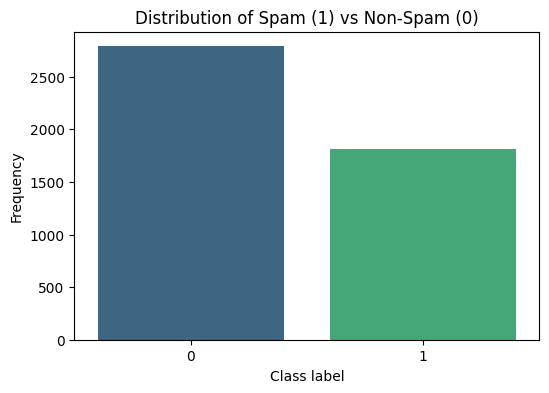

In [9]:

print("missing values:")
print(data.isnull().sum().sum())

plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=data, palette='viridis')
plt.title("Distribution of Spam (1) vs Non-Spam (0)")
plt.xlabel("Class label")
plt.ylabel("Frequency")
plt.show()

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

Data Preprocessing

In [10]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
std_scaler = StandardScaler()
X_train_scaled = std_scaler.fit_transform(X_train)
X_test_scaled = std_scaler.transform(X_test)
min_max_scaler = MinMaxScaler()
X_train_mm = min_max_scaler.fit_transform(X_train)
X_test_mm = min_max_scaler.transform(X_test)

def evaluate_model(y_true, y_pred, train_time, pred_time):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "Specificity": tn / (tn + fp),
        "False Positive Rate": fp / (fp + tn),
        "Training Time(s)": train_time,
        "Prediction Time(s)": pred_time
    }

Naïve Bayes Classification

naive bayes classification


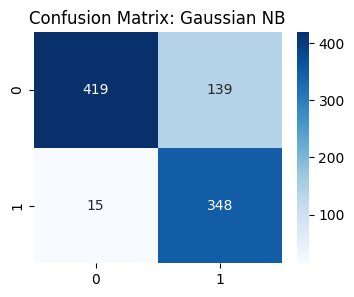

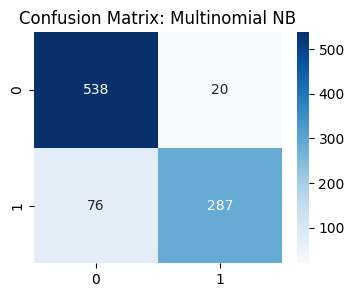

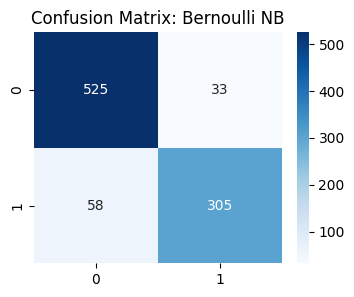

                Accuracy  Precision    Recall  F1 Score  Specificity  \
Model                                                                  
Gaussian NB     0.832790   0.714579  0.958678  0.818824     0.750896   
Multinomial NB  0.895765   0.934853  0.790634  0.856716     0.964158   
Bernoulli NB    0.901194   0.902367  0.840220  0.870185     0.940860   

                False Positive Rate  
Model                                
Gaussian NB                0.249104  
Multinomial NB             0.035842  
Bernoulli NB               0.059140  


In [11]:
print("naive bayes classification")
nb_models = {
    "Gaussian NB": (GaussianNB(), X_train_scaled, X_test_scaled),
    "Multinomial NB": (MultinomialNB(), X_train_mm, X_test_mm),
    "Bernoulli NB": (BernoulliNB(), X_train_scaled, X_test_scaled)
}

nb_performance = []

for name, (model, train_data, test_data) in nb_models.items():
    start_t = time.time()
    model.fit(train_data, y_train)
    t_train = time.time() - start_t

    start_p = time.time()
    y_pred = model.predict(test_data)
    t_pred = time.time() - start_p

    metrics = evaluate_model(y_test, y_pred, t_train, t_pred)
    metrics['Model'] = name
    nb_performance.append(metrics)

    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()


nb_df = pd.DataFrame(nb_performance).set_index('Model')
print(nb_df.iloc[:, :-2])

K-Nearest Neighbor (KNN) and Tuning

KNN


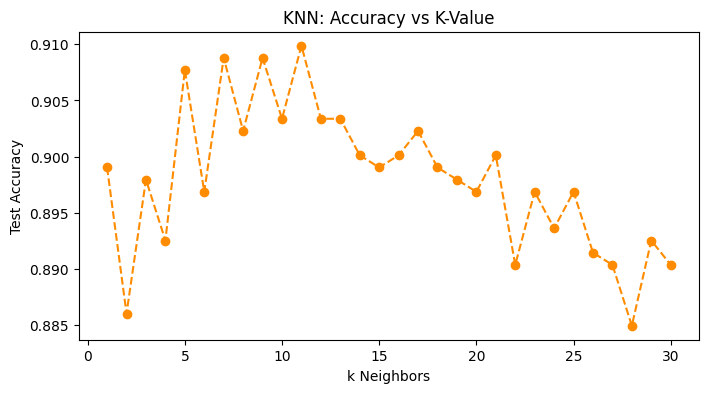

Best Params: {'algorithm': 'kd_tree', 'n_neighbors': 15, 'weights': 'distance'}
Best CV Accuracy: 0.9209


In [12]:
print("KNN")

accuracies = []
k_range = range(1, 31)
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(8, 4))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='darkorange')
plt.title("KNN: Accuracy vs K-Value")
plt.xlabel("k Neighbors")
plt.ylabel("Test Accuracy")
plt.show()


param_grid = {
    "n_neighbors": k_range,
    "weights": ["uniform", "distance"],
    "algorithm": ["kd_tree", "ball_tree"]
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"Best Params: {grid.best_params_}")
print(f"Best CV Accuracy: {grid.best_score_:.4f}")

Neighbor Search Algorithm Comparison

In [13]:
print("kd tree vs ball tree")

def compare_search_algos(algo_name):
    model = KNeighborsClassifier(
        n_neighbors=grid.best_params_["n_neighbors"],
        weights=grid.best_params_["weights"],
        algorithm=algo_name
    )

    start_t = time.time()
    model.fit(X_train_scaled, y_train)
    t_train = time.time() - start_t

    start_p = time.time()
    y_pred = model.predict(X_test_scaled)
    t_pred = time.time() - start_p

    return evaluate_model(y_test, y_pred, t_train, t_pred)

kd_results = compare_search_algos("kd_tree")
ball_results = compare_search_algos("ball_tree")

comparison_df = pd.DataFrame([kd_results, ball_results], index=["KDTree", "BallTree"])
print(comparison_df[["Accuracy", "Training Time(s)", "Prediction Time(s)"]])

kd tree vs ball tree
          Accuracy  Training Time(s)  Prediction Time(s)
KDTree    0.917481          0.037379            0.533208
BallTree  0.917481          0.026593            0.442934


ROC Curve Visualization

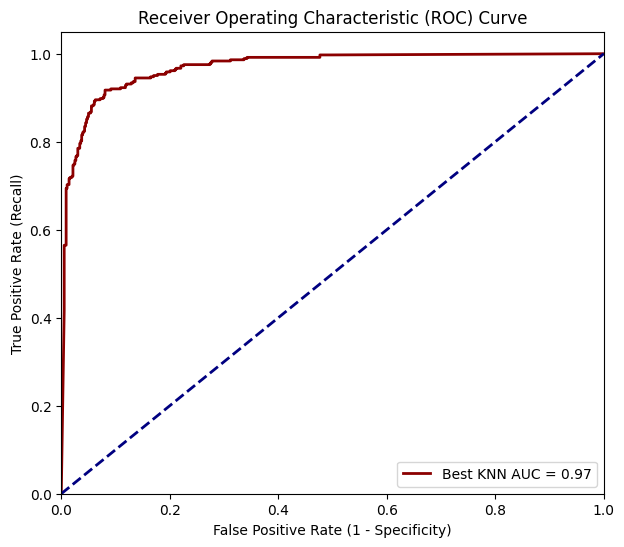

In [14]:

best_knn = grid.best_estimator_
y_prob = best_knn.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkred', lw=2, label=f"Best KNN AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()